# 1단계 — 데이터 수집

**목적**: yfinance(주가 9종) + FRED API(CPI) 수집 후 raw 저장  
**수집 기간**: 2019-12-01 ~ 2025-05-23 (lag 피처 생성용 여유분 포함)  
**산출물**:
- `data/raw/prices_raw.csv`
- `data/raw/cpi_raw.csv`

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()
np.random.seed(42)

In [2]:
# 상수 정의 
START_DATE = "2019-12-01"  # lag 피처 생성 여유분 포함 
END_DATE   = "2025-05-23" 

TICKERS = {
    "NVDA": "NVDA",
    "SOX": "^SOX",
    "TSM": "TSM",
    "QQQ": "QQQ",
    "DXY": "DX-Y.NYB",
    "VIX": "^VIX",
    "MSFT": "MSFT",
    "META": "META",
    "US_10Y_Yield": "^TNX",
}

FRED_SERIES = "CPIAUCSL"

RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f"수집 기간: {START_DATE} ~ {END_DATE}")
print(f"수집 티커: {list(TICKERS.keys())}")

수집 기간: 2019-12-01 ~ 2025-05-23
수집 티커: ['NVDA', 'SOX', 'TSM', 'QQQ', 'DXY', 'VIX', 'MSFT', 'META', 'US_10Y_Yield']


## 1. yfinance — 주가 데이터 수집

In [3]:
def download_prices(tickers: dict, start: str, end: str) -> pd.DataFrame:
    """yfinance로 복수 티커의 종가(Close)를 수집한다."""
    raw = yf.download(
        list(tickers.values()),
        start=start,
        end=end,
        auto_adjust=True,
        progress=True,
    )
    close = raw["Close"].copy()
    close.rename(columns={v: k for k, v in tickers.items()}, inplace=True)
    close.index.name = "Date"
    return close


prices_raw = download_prices(TICKERS, START_DATE, END_DATE)
print(f"\n수집 완료: {prices_raw.shape[0]}행 × {prices_raw.shape[1]}열")
prices_raw.tail(3)

[*********************100%***********************]  9 of 9 completed


수집 완료: 1377행 × 9열


Ticker,DXY,META,MSFT,NVDA,QQQ,TSM,SOX,US_10Y_Yield,VIX
Date,,,,,,,,,
2025-05-20,100.120003,635.118652,454.539337,134.348358,517.763794,191.083328,4890.779785,4.481,18.090000
2025-05-21,99.559998,633.523560,448.983734,131.768951,510.568573,189.414017,4802.709961,4.596,20.870001
2025-05-22,99.959999,634.590271,451.255554,132.798706,511.523987,193.789810,4775.470215,4.553,20.280001


In [4]:
# 기본 검증 
print("=== 기간 확인 ===")
print(f"시작: {prices_raw.index.min().date()}")
print(f"종료: {prices_raw.index.max().date()}")
print(f"거래일 수: {len(prices_raw):,}")
print()

null_counts = prices_raw.isnull().sum()
print("=== 결측치 ===")
if null_counts.any():
    print(null_counts[null_counts > 0])
else:
    print("없음")

=== 기간 확인 ===
시작: 2019-12-02
종료: 2025-05-22
거래일 수: 1,377

=== 결측치 ===
Ticker
META            1
MSFT            1
NVDA            1
QQQ             1
TSM             1
SOX             1
US_10Y_Yield    1
VIX             1
dtype: int64


## 2. FRED API — CPI 데이터 수집

In [5]:
def download_cpi(series_id: str, start: str, end: str) -> pd.DataFrame:
    """FRED API로 월간 CPI 시계열을 수집한다."""
    api_key = os.getenv("FRED_API_KEY", "").strip()
    if not api_key:
        raise EnvironmentError("FRED_API_KEY가 .env에 없습니다.")
    fred = Fred(api_key=api_key)
    series = fred.get_series(series_id, observation_start=start, observation_end=end)
    df = series.to_frame(name="US_CPI")
    df.index.name = "Date"
    return df


cpi_raw = download_cpi(FRED_SERIES, START_DATE, END_DATE)
print(f"CPI 수집 완료: {cpi_raw.shape[0]}개월")
cpi_raw.tail(5)

CPI 수집 완료: 66개월


,US_CPI
Date,
2025-01-01,318.961
2025-02-01,319.679
2025-03-01,319.785
2025-04-01,320.302
2025-05-01,320.620


In [6]:
print("=== CPI 검증 ===")
print(f"기간: {cpi_raw.index.min().date()} ~ {cpi_raw.index.max().date()}")
print(f"결측치: {cpi_raw.isnull().sum().values[0]}개")

=== CPI 검증 ===
기간: 2019-12-01 ~ 2025-05-01
결측치: 0개


## 3. 원본 저장

In [7]:
prices_path = RAW_DIR / "prices_raw.csv"
cpi_path = RAW_DIR / "cpi_raw.csv"

prices_raw.to_csv(prices_path)
cpi_raw.to_csv(cpi_path)

print(f"저장 완료:")
print(f"  {prices_path}  ({prices_path.stat().st_size / 1024:.1f} KB)")
print(f"  {cpi_path}  ({cpi_path.stat().st_size / 1024:.1f} KB)")

저장 완료:
  ../data/raw/prices_raw.csv  (232.8 KB)
  ../data/raw/cpi_raw.csv  (1.2 KB)


## 4. 시각화 — 수집 데이터 개요

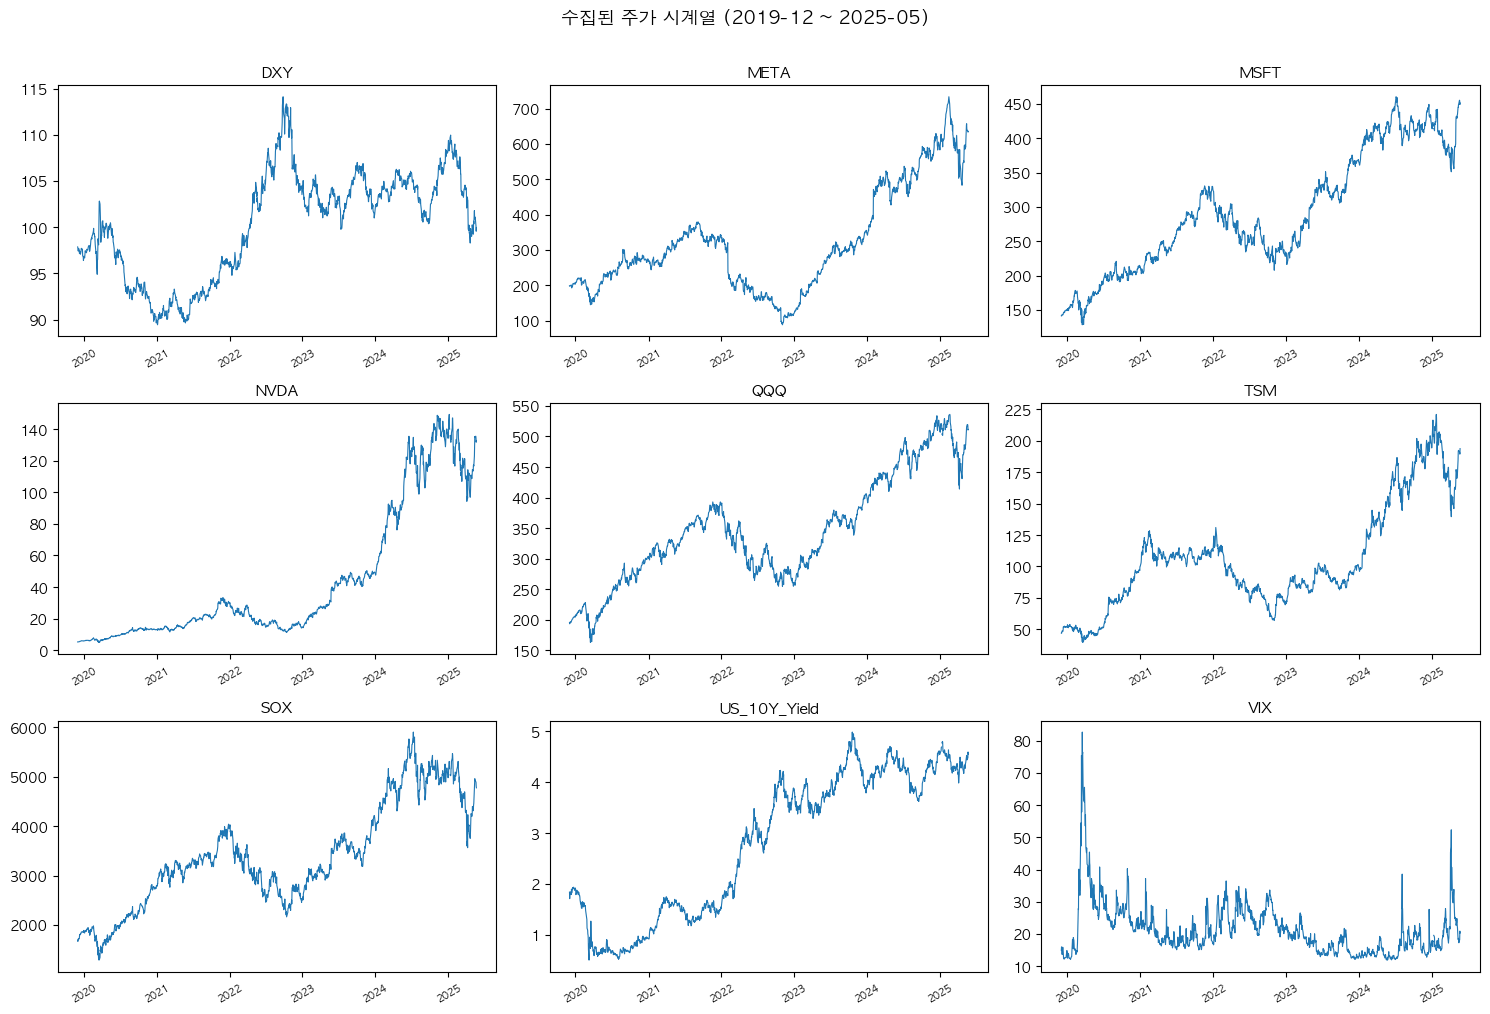

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(prices_raw.columns):
    axes[i].plot(prices_raw.index, prices_raw[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)

plt.suptitle("수집된 주가 시계열 (2019-12 ~ 2025-05)", fontsize=13, y=1.01)
plt.tight_layout()

fig_dir = Path("../reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "01_raw_prices_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("=" * 50)
print("1단계 데이터 수집 완료 요약")
print("=" * 50)
print(f"[주가] {prices_raw.shape[0]}거래일 × {prices_raw.shape[1]}종목")
print(f"기간: {prices_raw.index.min().date()} ~ {prices_raw.index.max().date()}")
print()
print(f"[CPI] {cpi_raw.shape[0]}개월")
print(f"기간: {cpi_raw.index.min().date()} ~ {cpi_raw.index.max().date()}")

1단계 데이터 수집 완료 요약
[주가] 1377거래일 × 9종목
기간: 2019-12-02 ~ 2025-05-22

[CPI] 66개월
기간: 2019-12-01 ~ 2025-05-01
